In [1]:
import sys 
import os
from pathlib import Path
from utils.data_io import read_data
import numpy as np
import h5py
import matplotlib.pyplot as plt

In [ ]:
help(read_data)


Help on function read_data in module utils.data_io:

read_data(fish, dir_voluseg)
    Load voluseg-processed timeseries, cell coordinates, and volume mean.

    Reads from: dir_voluseg / proj_ID / expt_ID / output /
        - cells0_clean.hdf5  (cell_timeseries, cell_x, cell_y, cell_z)
        - volume0.hdf5       (volume_mean)

    Parameters
    ----------
    fish : tuple of (str, str)
        (proj_ID, expt_ID).
    dir_voluseg : str
        Base path to voluseg data tree (config.dir_voluseg).

    Returns
    -------
    data_np : np.ndarray
        Cell timeseries, shape (n_cells, n_timepoints).
    volume_mean : np.ndarray
        Mean volume, transposed to (X, Y, Z).
    cell_x, cell_y, cell_z : np.ndarray
        Cell coordinates. NOTE: voluseg's cell_y maps to conceptual X,
        and voluseg's cell_x maps to conceptual Y (axis swap applied here).



In [3]:

sys.path.append('./Zebrafish-whole-brain-analysis')

#Paths

proj_ID = "hcrt-trpv1_huc-h2b-g8m_csn_120min"

#ID for each fish
expt_ids = ["251008_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish4", "251102_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish1", "251102_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish2", "251210_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish1",
    #"251210_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish2", 
    "251210_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish3", "260514_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish1", "260514_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish2", "260515_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish1"]

dir_voluseg = '/mnt/storage-raid10/Yun'

all_fish_data= {}

for fish_id in expt_ids:
    fish_name = ("hcrt-trpv1_huc-h2b-g8m_csn_120min", fish_id)
    print(f"Processing fish: {fish_name}")

    cell_timeseries, cell_x, cell_y, cell_z, volume_mean = read_data(fish_name, dir_voluseg)

    all_fish_data[fish_name] = {
        "cell_timeseries": cell_timeseries,
        "cell_x": cell_x,
        "cell_y": cell_y,
        "cell_z": cell_z,
        "volume_mean": volume_mean
    }


Processing fish: ('hcrt-trpv1_huc-h2b-g8m_csn_120min', '251008_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish4')
cell_x range: (np.int64(-1), np.int64(296)), cell_y range: (np.int64(-1), np.int64(574)), cell_z range: (np.int64(-1), np.int64(39))
Loaded raw hdf5 data as numpy array, shape: (40, 300, 580)
Transposed data numpy array shape into (X, Y, Z): (300, 580, 40)
Processing fish: ('hcrt-trpv1_huc-h2b-g8m_csn_120min', '251102_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish1')
cell_x range: (np.int64(-1), np.int64(314)), cell_y range: (np.int64(-1), np.int64(568)), cell_z range: (np.int64(-1), np.int64(39))
Loaded raw hdf5 data as numpy array, shape: (40, 316, 572)
Transposed data numpy array shape into (X, Y, Z): (316, 572, 40)
Processing fish: ('hcrt-trpv1_huc-h2b-g8m_csn_120min', '251102_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish2')
cell_x range: (np.int64(-1), np.int64(294)), cell_y range: (np.int64(-1), np.int64(569)), cell_z range: (np.int64(-1), np.int64(39))
Loaded raw hdf5 data as numpy array, shape: 

In [3]:
def show_fish_folders(project_path):
    if os.path.exists(project_path):
        print("Available Fish Folders:")
        for folder in os.listdir(project_path):
            print(f"- {folder}")
    else:
        print(f"Error: The base project path {project_path} doesn't exist yet.")

project_path = '/mnt/storage-raid10/Yun/hcrt-trpv1_huc-h2b-g8m_csn_120min/'
show_fish_folders(project_path)


def show_folder_contents(folder_path):
   if os.path.exists(folder_path):
        print("\nInside Fish 2 Folder")
        print(os.listdir(folder_path))
    else:
        print(f"Error: The folder {folder_path} doesn't exist yet.")
folder_path = os.path.join(project_path, '251210_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish2')
show_folder_contents(folder_path)


def show_output_folder_contents(output_path):
    if os.path.exists(output_path):
        print("\nInside Output Folder")
        print(os.listdir(output_path))
    else:
        print("\nStatus: The 'output' folder has not been created yet.")
output_path = os.path.join(folder_path, 'output')
show_output_folder_contents(output_path)


'''
if os.path.exists(fish_path):
    print("\nInside Fish 2 Folder")
    print(os.listdir(fish_path))
    
    output_path = os.path.join(fish_path, 'output')
    if os.path.exists(output_path):
        print("\nInside Output Folder")
        print(os.listdir(output_path))
    else:
        print("\nStatus: The 'output' folder has not been created yet.")
else:
    print(f"\nStatus: The folder '251210_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish2' does not exist yet.")
'''

IndentationError: unindent does not match any outer indentation level (<string>, line 17)

In [ ]:
def show_variables(fish):
    dir_voluseg = "/mnt/storage-raid10/Yun"
    cell_timeseries, volume_mean, cell_x, cell_y, cell_z = read_data(fish, dir_voluseg)
    print(f"\nVariables for fish: {fish}")
    print(f"cell_timeseries shape: {cell_timeseries.shape}")
    print(f"volume_mean shape: {volume_mean.shape}")
    print(f"cell_x shape: {cell_x.shape}")
    print(f"cell_y shape: {cell_y.shape}")
    print(f"cell_z shape: {cell_z.shape}")


fish = ("hcrt-trpv1_huc-h2b-g8m_csn_120min", "251210_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish2")
show_variables(fish)

cell_x range: (np.int64(-1), np.int64(301)), cell_y range: (np.int64(-1), np.int64(561)), cell_z range: (np.int64(-1), np.int64(39))
Loaded raw hdf5 data as numpy array, shape: (40, 304, 564)
Transposed data numpy array shape into (X, Y, Z): (304, 564, 40)


In [ ]:
#NOTE: voluseg's cell_y maps to conceptual X,
        #and voluseg's cell_x maps to conceptual Y (axis swap applied here).

In [ ]:
#Cell X, Y, Z coordinates are first output from read_data, and are used to map the cell_timeseries to the 3D volume.
#Cell timeseries is second output from read_data, and is a 2D array where each row corresponds to a cell and each column corresponds to a time point. The volume_mean is a 1D array representing the mean intensity of the entire volume at each time point.
#Volume mean is third output from read_data, and is a 1D array representing the mean intensity of the entire volume at each time point.

In [ ]:
'''
Processing fish: ('hcrt-trpv1_huc-h2b-g8m_csn_120min', '251008_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish4')
cell_x range: (np.int64(-1), np.int64(296)), cell_y range: (np.int64(-1), np.int64(574)), cell_z range: (np.int64(-1), np.int64(39))
Loaded raw hdf5 data as numpy array, shape: (40, 300, 580)
Transposed data numpy array shape into (X, Y, Z): (300, 580, 40)

Processing fish: ('hcrt-trpv1_huc-h2b-g8m_csn_120min', '251102_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish1')
cell_x range: (np.int64(-1), np.int64(314)), cell_y range: (np.int64(-1), np.int64(568)), cell_z range: (np.int64(-1), np.int64(39))
Loaded raw hdf5 data as numpy array, shape: (40, 316, 572)
Transposed data numpy array shape into (X, Y, Z): (316, 572, 40)

Processing fish: ('hcrt-trpv1_huc-h2b-g8m_csn_120min', '251102_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish2')
cell_x range: (np.int64(-1), np.int64(294)), cell_y range: (np.int64(-1), np.int64(569)), cell_z range: (np.int64(-1), np.int64(39))
Loaded raw hdf5 data as numpy array, shape: (40, 296, 572)
Transposed data numpy array shape into (X, Y, Z): (296, 572, 40)

Processing fish: ('hcrt-trpv1_huc-h2b-g8m_csn_120min', '251210_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish1')
cell_x range: (np.int64(-1), np.int64(298)), cell_y range: (np.int64(-1), np.int64(550)), cell_z range: (np.int64(-1), np.int64(39))
Loaded raw hdf5 data as numpy array, shape: (40, 300, 552)
Transposed data numpy array shape into (X, Y, Z): (300, 552, 40)

Processing fish: ('hcrt-trpv1_huc-h2b-g8m_csn_120min', '251210_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish2')
cell_x range: (np.int64(-1), np.int64(301)), cell_y range: (np.int64(-1), np.int64(561)), cell_z range: (np.int64(-1), np.int64(39))
Loaded raw hdf5 data as numpy array, shape: (40, 304, 564)
Transposed data numpy array shape into (X, Y, Z): (304, 564, 40)

Processing fish: ('hcrt-trpv1_huc-h2b-g8m_csn_120min', '251210_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish3')
cell_x range: (np.int64(-1), np.int64(299)), cell_y range: (np.int64(-1), np.int64(559)), cell_z range: (np.int64(-1), np.int64(38))
Loaded raw hdf5 data as numpy array, shape: (40, 300, 564)
Transposed data numpy array shape into (X, Y, Z): (300, 564, 40)

Processing fish: ('hcrt-trpv1_huc-h2b-g8m_csn_120min', '260514_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish1')
cell_x range: (np.int64(-1), np.int64(278)), cell_y range: (np.int64(-1), np.int64(542)), cell_z range: (np.int64(-1), np.int64(39))
Loaded raw hdf5 data as numpy array, shape: (40, 280, 544)
Transposed data numpy array shape into (X, Y, Z): (280, 544, 40)

Processing fish: ('hcrt-trpv1_huc-h2b-g8m_csn_120min', '260514_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish2')
cell_x range: (np.int64(-1), np.int64(278)), cell_y range: (np.int64(-1), np.int64(569)), cell_z range: (np.int64(-1), np.int64(39))
Loaded raw hdf5 data as numpy array, shape: (40, 280, 572)
Transposed data numpy array shape into (X, Y, Z): (280, 572, 40)

Processing fish: ('hcrt-trpv1_huc-h2b-g8m_csn_120min', '260515_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish1')
cell_x range: (np.int64(-1), np.int64(285)), cell_y range: (np.int64(-1), np.int64(564)), cell_z range: (np.int64(-1), np.int64(39))
Loaded raw hdf5 data as numpy array, shape: (40, 288, 568)
Transposed data numpy array shape into (X, Y, Z): (288, 568, 40)

'''

In [7]:
import h5py

with h5py.File('/mnt/storage-raid10/Yun/hcrt-trpv1_huc-h2b-g8m_csn_120min/251102_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish2/output/volume0.hdf5', 'r') as f:
    print("Datasets are:", list(f.keys()))


Datasets are: ['background', 'block_valids', 'block_xyz0', 'block_xyz1', 'n_blocks', 'n_voxels_cell', 'thr_intensity', 'thr_probability', 'volume_mask', 'volume_mean', 'volume_peak']


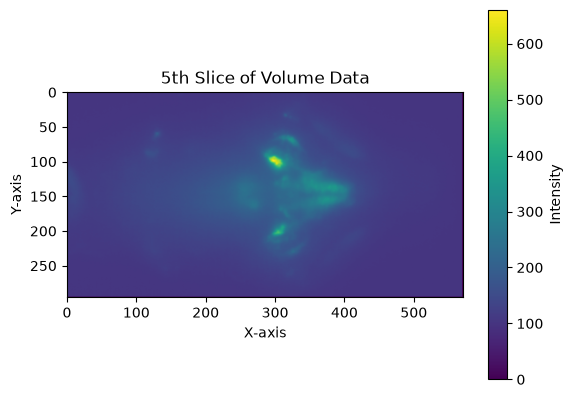

In [2]:
with h5py.File('/mnt/storage-raid10/Yun/hcrt-trpv1_huc-h2b-g8m_csn_120min/251102_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish2/output/volume0.hdf5', 'r') as f:
     volume_data = f['volume_mean'][:]

plt.imshow(volume_data[4, :, :], cmap='viridis')
plt.colorbar(label='Intensity')
plt.title('5th Slice of Volume Data')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.show()

In [ ]:
print(f'cell_timeseries shape: {cell_timeseries.shape}')
array = np.array(cell_timeseries)
print(f'cell_timeseries array shape: {array.shape}, size: {array.size}, ndim: {array.ndim}')



cell_timeseries shape: (516321, 7200)
cell_timeseries array shape: (516321, 7200), size: 3717511200, ndim: 2
[[118.68107  118.06138  117.38853  117.579094 118.881134]
 [122.45092  122.376755 118.21208  123.230064 120.46463 ]
 [123.38421  124.478264 125.95104  128.58626  128.5566  ]
 [116.25974  119.16177  122.165596 127.19039  127.36414 ]
 [126.99806  126.40884  125.82283  123.80545  127.78695 ]]


In [2]:
import os
import matplotlib.pyplot as plt
import numpy as np

sys.path.append('./Zebrafish-whole-brain-analysis')

#Paths

proj_ID = "hcrt-trpv1_huc-h2b-g8m_csn_120min"

#ID for each fish
expt_ids = ["251008_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish4",
            "251102_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish1",
            "251102_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish2",
            "251210_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish1",
           #"251210_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish2", 
            "251210_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish3",
            "260514_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish1",
            "260514_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish2",
            "260515_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish1"
]

dir_voluseg = '/mnt/storage-raid10/Yun'


all_fish_data = {}
output_dir = "./fish_plots"
os.makedirs(output_dir, exist_ok=True)

for fish_id in expt_ids:
    fish_name = ("hcrt-trpv1_huc-h2b-g8m_csn_120min", fish_id)
    print(f"\nProcessing fish: {fish_id}")
    
    cell_timeseries,  volume_mean, cell_x, cell_y, cell_z = read_data(fish_name, dir_voluseg)
    
    all_fish_data[fish_name] = {
        "cell_timeseries": cell_timeseries,
        "volume_mean": volume_mean,
        "cell_x": cell_x,
        "cell_y": cell_y,
        "cell_z": cell_z
    }

    #Convert multi-pixel cells into single cell centroids!
    mask = (cell_x != -1) & (cell_y != -1) & (cell_z != -1)
    mx = np.ma.masked_array(cell_x, mask=~mask)
    my = np.ma.masked_array(cell_y, mask=~mask)
    mz = np.ma.masked_array(cell_z, mask=~mask)
    
  
    x_coords = mx.mean(axis=1).filled(np.nan)
    y_coords = my.mean(axis=1).filled(np.nan)
    z_coords = mz.mean(axis=1).filled(np.nan)
    

    valid = ~np.isnan(x_coords)
    x_coords = x_coords[valid]
    y_coords = y_coords[valid]
    z_coords = z_coords[valid]
    
    try:
        fig = plt.figure(figsize=(10, 7))
        ax = fig.add_subplot(111, projection='3d') # Fixed typo
        
        scatter = ax.scatter(x_coords, y_coords, z_coords, c=z_coords, cmap='viridis', s=2, alpha=0.6)
        
        ax.set_title(f"Spatial Coordinates: {fish_id}", fontsize=14, pad=20)
        ax.set_xlabel('X Axis (μm)', labelpad=10)
        ax.set_ylabel('Y Axis (μm)', labelpad=10)
        ax.set_zlabel('Z Axis (μm)', labelpad=10)

        ax.set_xlim(0, 300)
        ax.set_ylim(0, 600)
        ax.set_zlim(0, 40)
        
        cbar = fig.colorbar(scatter, ax=ax, pad=0.1, shrink=0.6)
        cbar.set_label('Z Depth / Cortical Layer', rotation=270, labelpad=15)
        
        ax.view_init(elev=20, azim=45)
        
        # Save plot to folder
        save_path = os.path.join(output_dir, f"{fish_id}_spatial_plot.png")
        plt.savefig(save_path, bbox_inches='tight', dpi=150)
        plt.close(fig)
        print(f"Saved plot to {save_path}\n")
        
    except Exception as e:
        print(f"Error plotting {fish_id}: {e}")
        if 'fig' in locals():
            plt.close(fig)

print("\nFinished running")



Processing fish: 251008_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish4
cell_x range: (np.int64(-1), np.int64(296)), cell_y range: (np.int64(-1), np.int64(574)), cell_z range: (np.int64(-1), np.int64(39))
Loaded raw hdf5 data as numpy array, shape: (40, 300, 580)
Transposed data numpy array shape into (X, Y, Z): (300, 580, 40)
Saved plot to ./fish_plots/251008_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish4_spatial_plot.png


Processing fish: 251102_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish1
cell_x range: (np.int64(-1), np.int64(314)), cell_y range: (np.int64(-1), np.int64(568)), cell_z range: (np.int64(-1), np.int64(39))
Loaded raw hdf5 data as numpy array, shape: (40, 316, 572)
Transposed data numpy array shape into (X, Y, Z): (316, 572, 40)
Saved plot to ./fish_plots/251102_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish1_spatial_plot.png


Processing fish: 251102_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish2
cell_x range: (np.int64(-1), np.int64(294)), cell_y range: (np.int64(-1), np.int64(569)), cell_z range: (np.int64(-1)

In [4]:
# 1. Read the data
cell_timeseries, cell_x, cell_y, cell_z, volume_mean = read_data(fish_name, dir_voluseg)

# ---- DIAGNOSTIC PRINTS ----
print(f"--- Checking shapes for {fish_id} ---")
for name, var in [("timeseries", cell_timeseries), ("x", cell_x), ("y", cell_y), ("z", cell_z), ("vol", volume_mean)]:
    if hasattr(var, 'shape'):
        print(f"  {name} shape: {var.shape}")
    else:
        print(f"  {name} type: {type(var)} (No shape attribute)")
print("-------------------------------------")


cell_x range: (np.int64(-1), np.int64(296)), cell_y range: (np.int64(-1), np.int64(574)), cell_z range: (np.int64(-1), np.int64(39))
Loaded raw hdf5 data as numpy array, shape: (40, 300, 580)
Transposed data numpy array shape into (X, Y, Z): (300, 580, 40)
--- Checking shapes for 251008_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish4 ---
  timeseries shape: (581225, 7200)
  x shape: (300, 580, 40)
  y shape: (581225, 29)
  z shape: (581225, 29)
  vol shape: (581225, 29)
-------------------------------------


Successfully loaded 516321 real cell coordinates!


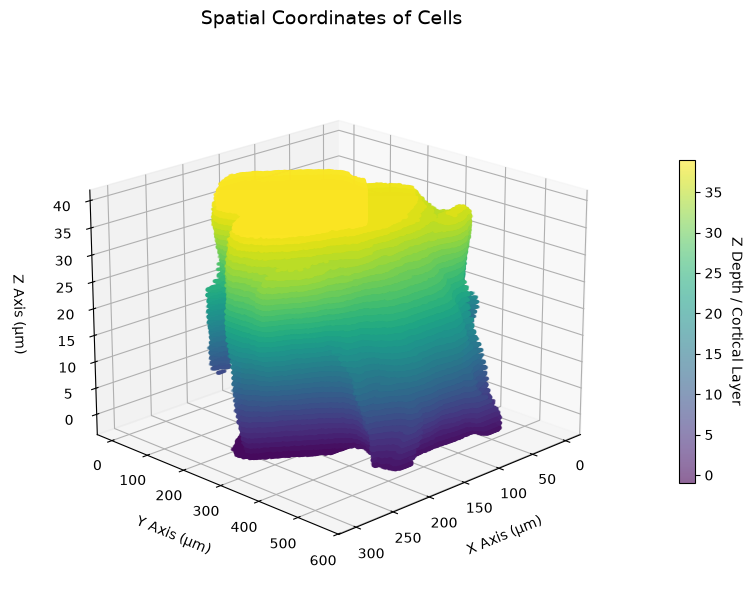

In [18]:
try:
  
    x_coords = cell_x
    y_coords = cell_y
    z_coords = cell_z
    plot_title = "Spatial Coordinates of Cells"
    print(f"Successfully loaded {len(x_coords)} real cell coordinates!")

except NameError:
    print("error")



fig = plt.figure(figsize=(10, 7))
ax = fig.add_extend = fig.add_subplot(111, projection='3d')


scatter = ax.scatter(x_coords, y_coords, z_coords, c=z_coords, cmap='viridis', s=2, alpha=0.6)

ax.set_title(plot_title, fontsize=14, pad=20)
ax.set_xlabel('X Axis (μm)', labelpad=10)
ax.set_ylabel('Y Axis (μm)', labelpad=10)
ax.set_zlabel('Z Axis (μm)', labelpad=10)

cbar = fig.colorbar(scatter, ax=ax, pad=0.1, shrink=0.6)
cbar.set_label('Z Depth / Cortical Layer', rotation=270, labelpad=15)

ax.view_init(elev=20, azim=45)
plt.show()
